# TP3 - Visión por computadora
## Andrés García | a2406
## Martin Gabriel Quiroga | a2412

## Punto 1

De manera general, para este punto se tratará de partir desde las imágenes más simples hacia las más complejas. En general se va a aplicar detección de bordes con Canny para aislarnos de los asuntos de color e intensidades para el template matching (se compara borde contra borde). Luego, en algunos casos donde hay presencia de ruido, se aplicarán filtros gaussianos o de mediana para ayudar a la detección. En algún caso también se aplica unsharp masking para resaltar los bordes del logo mediante el aumento de las componentes de alta frecuencia antes de aplicar canny.

En general siempre hay una etapa inicial de aplicación de filtros y canny. Luego se aplica el template matching ajustando la escala para que coincida lo mejor posible. Luego de encontrar alguna escala de detección, se realiza un barrido por las escalas aledañas, realizando en cada una la detección para encontrar la escala que produce máximo score. Vale aclarar que en algunas oportunidades se escala el template y en otras la imagen.

### Inicio con *coca_retro_1* (simpleza)

Se inicia el desarrollo del algoritmo de detección por template matching con la imagen del logo retro de coca dado que tiene el logo en negro y es simple (tiene sólo texto agregado y no demasiadas formas como botellas y demás). El template, al ser rojo sobre blanco, al pasar a escala de grises queda logo gris con fondo blanco lo cuál lo hace más simple para el matching.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# se levanta imagen y template directo en grises
template = cv2.imread(r'template\pattern.png', cv2.IMREAD_GRAYSCALE)
img      = cv2.imread(r'images\coca_retro_1.png', cv2.IMREAD_GRAYSCALE)

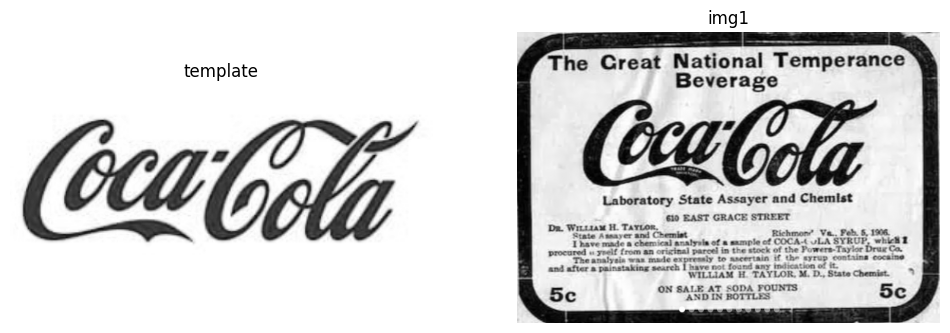

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(template, cmap='gray')
axes[0].axis('off')
axes[0].set_title('template')
axes[1].imshow(img, cmap='gray')
axes[1].axis('off')
axes[1].set_title('img1')
plt.show()

In [ ]:
# se mira el size de ambos
print("Template shape:", template.shape)
print("Imagen shape:", img.shape)

Template shape: (175, 400)
Imagen shape: (493, 715)


Por los tamaños y distribución de logos en las imagenes se estima que se deberá reducir el tamaño del template. Se realiza entones un primer template matching sin escala para visualizar el valor inicial del score del algoritmo y luego ver el box, lo cuál da una idea de la reducción necesaria.

In [ ]:
resultado = cv2.matchTemplate(img, template, cv2.TM_CCOEFF_NORMED)

min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(resultado)
print("Max value:", max_val)
print("Max location:", max_loc)

Max value: 0.2711469531059265
Max location: (108, 104)


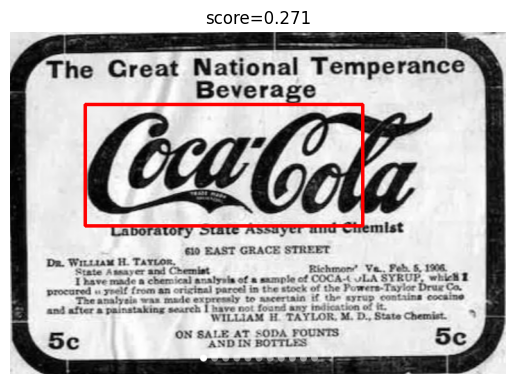

In [5]:
h, w = template.shape   # (175, 400) → h=175, w=400

img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
x, y = max_loc
cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (255, 0, 0), 3)

plt.imshow(img_rgb); plt.axis('off')
plt.title(f"score={max_val:.3f}")
plt.show()

Se observa que si bien el score es bajo, el template ya logra ubicarse sobre el logo. A continuación se reduce la escala de la imagen a mano para buscar el mejor valor de detección.

escala=0.75  score=0.692


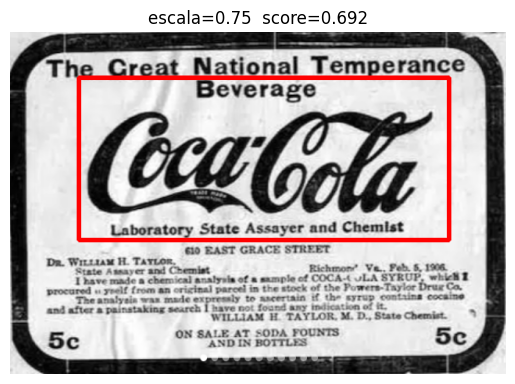

In [15]:
escala = 0.75
img_s = cv2.resize(img, (0, 0), fx=escala, fy=escala, interpolation=cv2.INTER_AREA)

resultado = cv2.matchTemplate(img_s, template, cv2.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(resultado)
print(f"escala={escala}  score={max_val:.3f}")

img_rgb = cv2.cvtColor(img_s, cv2.COLOR_GRAY2RGB)
x, y = max_loc
cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (255, 0, 0), 3)
plt.imshow(img_rgb); plt.axis('off')
plt.title(f"escala={escala}  score={max_val:.3f}")
plt.show()

Mejor escala: 0.750  score: 0.692


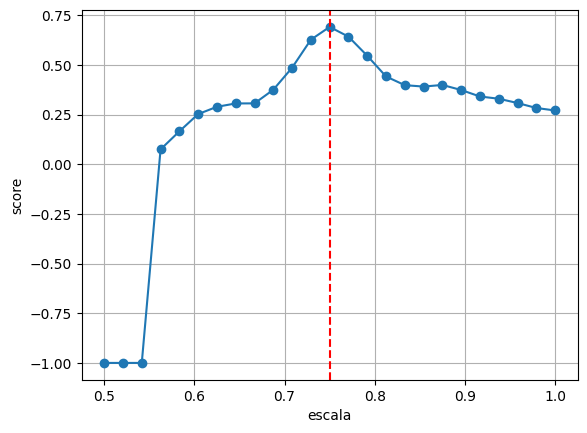

In [19]:
escalas = np.linspace(0.5, 1, 25)
scores = []

for escala in escalas:
    interp = cv2.INTER_AREA if escala < 1 else cv2.INTER_LINEAR
    img_s = cv2.resize(img, (0, 0), fx=escala, fy=escala, interpolation=interp)
    if img_s.shape[0] < h or img_s.shape[1] < w:
        scores.append(-1)
        continue
    res = cv2.matchTemplate(img_s, template, cv2.TM_CCOEFF_NORMED)
    _, max_val, _, _ = cv2.minMaxLoc(res)
    scores.append(max_val)

scores = np.array(scores)
mejor = escalas[np.argmax(scores)]
print(f"Mejor escala: {mejor:.3f}  score: {scores.max():.3f}")

plt.plot(escalas, scores, marker='o')
plt.axvline(mejor, color='r', ls='--')
plt.xlabel('escala'); plt.ylabel('score'); plt.grid(True)
plt.show()

Se logra la detección sin faltos positivos y se confirma la escala para el resultado óptimo.

### Imagen _coca_logo_1_

In [37]:
img2 = cv2.imread(r'images\coca_logo_1.png', cv2.IMREAD_GRAYSCALE)

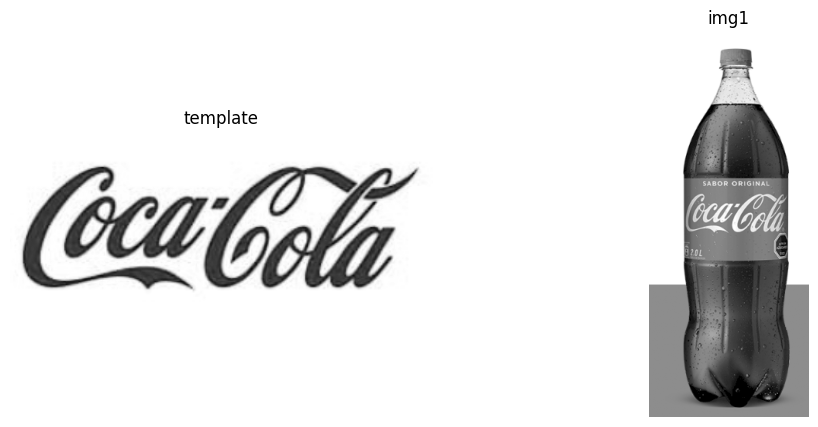

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(template, cmap='gray')
axes[0].axis('off')
axes[0].set_title('template')
axes[1].imshow(img2, cmap='gray')
axes[1].axis('off')
axes[1].set_title('img1')
plt.show()

En este caso que el template es mayor a la imagen, hay que reducirlo no sólo para que el matching funciones sino para que opencv no de error.

In [40]:
escala = 0.2
template_s = cv2.resize(template, (0, 0), fx=escala, fy=escala, interpolation=cv2.INTER_AREA)

resultado = cv2.matchTemplate(img2, template_s, cv2.TM_CCOEFF_NORMED)

min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(resultado)
print("Max value:", max_val)
print("Max location:", max_loc)

Max value: 0.3233542740345001
Max location: (89, 290)


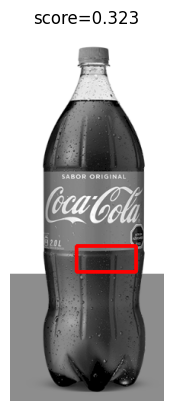

In [41]:
h, w = template_s.shape

img_rgb_2 = cv2.cvtColor(img2, cv2.COLOR_GRAY2RGB)
x, y = max_loc
cv2.rectangle(img_rgb_2, (x, y), (x + w, y + h), (255, 0, 0), 3)

plt.imshow(img_rgb_2); plt.axis('off')
plt.title(f"score={max_val:.3f}")
plt.show()

Se observa que el template es demasido chico.

Max value: 0.32622379064559937
Max location: (30, 425)


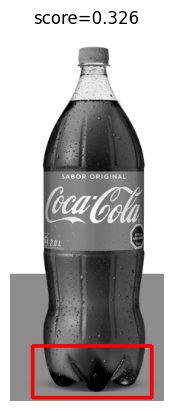

In [44]:
escala = 0.4
template_s = cv2.resize(template, (0, 0), fx=escala, fy=escala, interpolation=cv2.INTER_AREA)

resultado = cv2.matchTemplate(img2, template_s, cv2.TM_CCOEFF_NORMED)

min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(resultado)
print("Max value:", max_val)
print("Max location:", max_loc)

h, w = template_s.shape

img_rgb_2 = cv2.cvtColor(img2, cv2.COLOR_GRAY2RGB)
x, y = max_loc
cv2.rectangle(img_rgb_2, (x, y), (x + w, y + h), (255, 0, 0), 3)

plt.imshow(img_rgb_2); plt.axis('off')
plt.title(f"score={max_val:.3f}")
plt.show()

Luego de algunas iteraciones donde se lleva el template aproximadamente al tamaño del logo de la imagen se comprueba que el algoritmo no logra detectar el logo, produce falso positivo.

Este problema por el momento se atribuye a que la imagen original es logo blanco sobre etiqueta roja y el template es logo rojo sobre blanco. A pesar de que están "invertidos", el algoritmo no logra encontrar la correlación negativa tampoco.

Se pasa a probar trabajar con los bordes.

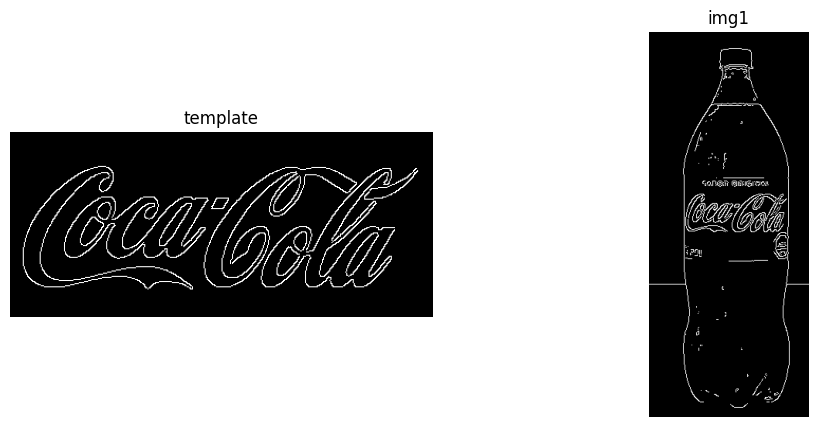

In [92]:
# inicialmente los umbrales de canny para imagen y template habían sido seteados en 50 y 100 respectivamente
# luego se configuraron distintos umbrales para ambas buscando optimizar la finura de los bordes

template_edges = cv2.Canny(template, 100, 150)
img2_edges = cv2.Canny(img2, 300, 350)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(template_edges, cmap='gray')
axes[0].axis('off')
axes[0].set_title('template')
axes[1].imshow(img2_edges, cmap='gray')
axes[1].axis('off')
axes[1].set_title('img1')
plt.show()

El resultado de Canny para la botella se observa un tanto "ruidoso", pero se realiza así como está el template matching para evaluar si ahora el logo es detectado.

Se escala el templatea 0.4 aproximado.

Max value: 0.21921691298484802
Max location: (34, 200)


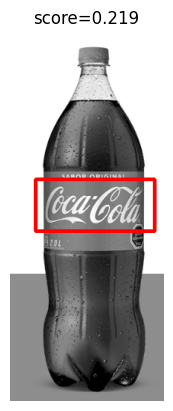

In [93]:
escala = 0.4
template_s = cv2.resize(template_edges, (0, 0), fx=escala, fy=escala, interpolation=cv2.INTER_AREA)

resultado = cv2.matchTemplate(img2_edges, template_s, cv2.TM_CCOEFF_NORMED)

min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(resultado)
print("Max value:", max_val)
print("Max location:", max_loc)

h, w = template_s.shape

img_rgb_2 = cv2.cvtColor(img2, cv2.COLOR_GRAY2RGB)
x, y = max_loc
cv2.rectangle(img_rgb_2, (x, y), (x + w, y + h), (255, 0, 0), 3)

plt.imshow(img_rgb_2); plt.axis('off')
plt.title(f"score={max_val:.3f}")
plt.show()

Se observa que el logo es detactado, sin embargo el score no es muy alto.

Se implementan diferentes escalas para encontrar la mejor igual que para la imagen anterior, pero ahora variando el template.

Mejor escala: 0.433  score: 0.421


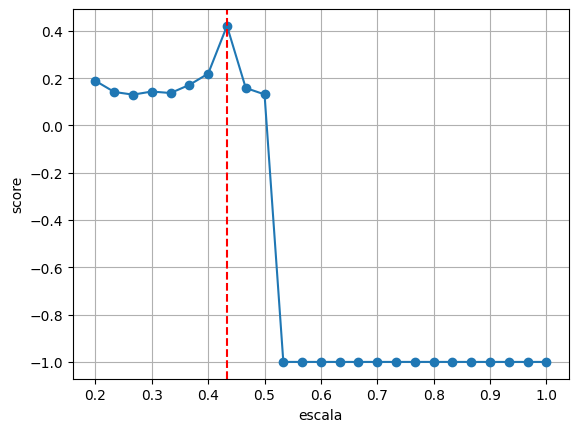

In [94]:
H, W = img2_edges.shape[:2]          # dimensiones de la imagen (fija)

escalas = np.linspace(0.2, 1.0, 25)
scores = []

for escala in escalas:
    interp = cv2.INTER_AREA if escala < 1 else cv2.INTER_LINEAR
    template_s = cv2.resize(template_edges, (0, 0), fx=escala, fy=escala, interpolation=interp)
    th, tw = template_s.shape[:2]
    if th > H or tw > W:             # el template no puede exceder la imagen
        scores.append(-1)
        continue
    res = cv2.matchTemplate(img2_edges, template_s, cv2.TM_CCOEFF_NORMED)
    _, max_val, _, _ = cv2.minMaxLoc(res)
    scores.append(max_val)

scores = np.array(scores)
mejor = escalas[np.argmax(scores)]
print(f"Mejor escala: {mejor:.3f}  score: {scores.max():.3f}")

plt.plot(escalas, scores, marker='o')
plt.axvline(mejor, color='r', ls='--')
plt.xlabel('escala'); plt.ylabel('score'); plt.grid(True)
plt.show()

Se observa una escala para la cual se produce un máximo de 0.421.

### Imagen *coca_logo_2*

Para este caso se probó inicialmente sin blur, y luego con blur gaussiano para suavizar la imagen. Sin embargo se observaba que los puntos del diseño que estaban arriba del logo generaban mayor correlación con el template. Es por eso que se aplica el blur de mediana que ayuda a la eliminación de los puntos.

Se realizan algunas iteraciones para lograr "ecualizar" en un punto adecuado el aporte tanto de medianBlur como de Canny en su conjunto para la detección del logo.

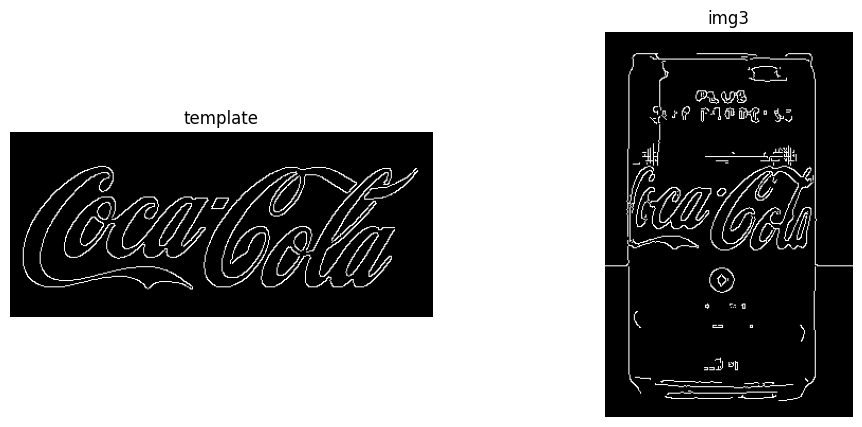

In [147]:
img3 = cv2.imread(r'images\coca_logo_2.png', cv2.IMREAD_GRAYSCALE)

template_edges = cv2.Canny(template, 100, 150)

img3_med   = cv2.medianBlur(img3, 5) 
img3_edges = cv2.Canny(img3_med, 100, 150)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(template_edges, cmap='gray')
axes[0].axis('off')
axes[0].set_title('template')
axes[1].imshow(img3_edges, cmap='gray')
axes[1].axis('off')
axes[1].set_title('img3')
plt.show()

In [137]:
# se mira el size de ambos
print("Template shape:", template.shape)
print("Imagen shape:", img3.shape)

Template shape: (175, 400)
Imagen shape: (363, 233)


Max value: 0.11124446988105774
Max location: (6, 116)


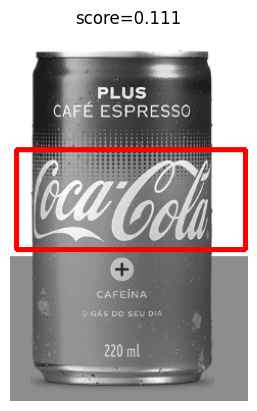

In [169]:
escala = 0.56
template_s = cv2.resize(template_edges, (0, 0), fx=escala, fy=escala, interpolation=cv2.INTER_AREA)

resultado = cv2.matchTemplate(img3_edges, template_s, cv2.TM_CCOEFF_NORMED)

min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(resultado)
print("Max value:", max_val)
print("Max location:", max_loc)

h, w = template_s.shape

img_rgb_3 = cv2.cvtColor(img3, cv2.COLOR_GRAY2RGB)
x, y = max_loc
cv2.rectangle(img_rgb_3, (x, y), (x + w, y + h), (255, 0, 0), 3)

plt.imshow(img_rgb_3); plt.axis('off')
plt.title(f"score={max_val:.3f}")
plt.show()

Mejor escala: 0.200  score: 0.184


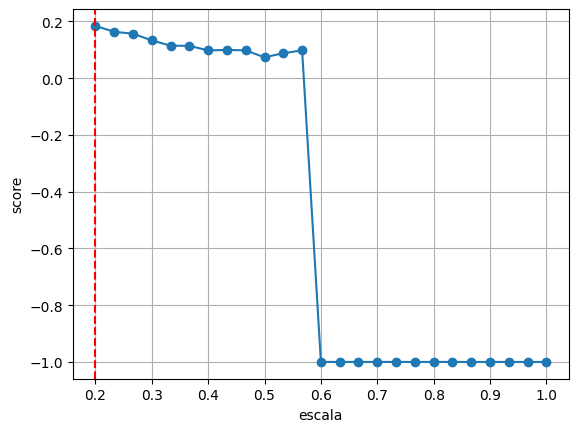

In [166]:
H, W = img3_edges.shape[:2]          # dimensiones de la imagen (fija)

escalas = np.linspace(0.2, 1.0, 25)
scores = []

for escala in escalas:
    interp = cv2.INTER_AREA if escala < 1 else cv2.INTER_LINEAR
    template_s = cv2.resize(template_edges, (0, 0), fx=escala, fy=escala, interpolation=interp)
    th, tw = template_s.shape[:2]
    if th > H or tw > W:             # el template no puede exceder la imagen
        scores.append(-1)
        continue
    res = cv2.matchTemplate(img3_edges, template_s, cv2.TM_CCOEFF_NORMED)
    _, max_val, _, _ = cv2.minMaxLoc(res)
    scores.append(max_val)

scores = np.array(scores)
mejor = escalas[np.argmax(scores)]
print(f"Mejor escala: {mejor:.3f}  score: {scores.max():.3f}")

plt.plot(escalas, scores, marker='o')
plt.axvline(mejor, color='r', ls='--')
plt.xlabel('escala'); plt.ylabel('score'); plt.grid(True)
plt.show()

Este caso merece algunos comentarios especiales. La curvatura de la lata y la presencia del diseño de la lata que incluye los puntos cerca del logo fuerzan a una ventana muy pequeña de configuración de parámetros para que el TM logre dar con el logo (y lo hace con un score bajo).

Cuando se realiza la curva de escalas para encontrar la escala que optimiza el score se encuentra que:
- 0.6 es la escala donde el template es más grande que la imagen y el algoritmo de cv2 muestra el error.
- Se observa un máximo en escala 0.2. Sin embargo es un punto de falso positivo. El aumento en el valor de correlación puede deberse a que al ser un template muy pequeño (pocos píxeles) es muy probable que haya una zona ruidosa en la imagen que genere mayor correlación que un template grande con el logo, donde los píxeles que tienen que coincidir son muchos.
- Luego, se observa que recién a partir de 0.5 se da el verdadero positivo y se encuentra su máximo en 0.56 aprox.

Es un caso límite, TM no es la mejor técnica para esta detección, como quizás si lo sería descriptores.

### Imagen *COCA-COLA-LOGO*

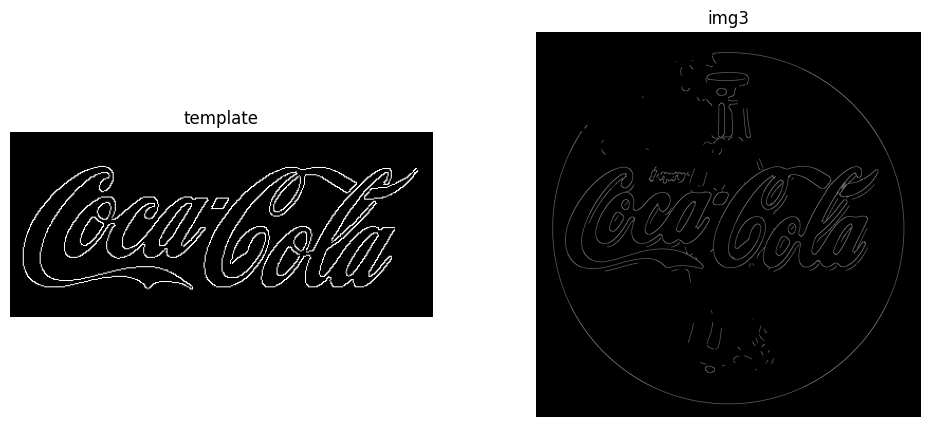

In [248]:
img4 = cv2.imread(r'images\COCA-COLA-LOGO.jpg', cv2.IMREAD_GRAYSCALE)

template_edges = cv2.Canny(template, 100, 150)

img4_med   = cv2.medianBlur(img4, 21) 
img4_edges = cv2.Canny(img4_med, 300, 350)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(template_edges, cmap='gray')
axes[0].axis('off')
axes[0].set_title('template')
axes[1].imshow(img4_edges, cmap='gray')
axes[1].axis('off')
axes[1].set_title('img3')
plt.show()

In [178]:
# se mira el size de ambos
print("Template shape:", template.shape)
print("Imagen shape:", img4.shape)

Template shape: (175, 400)
Imagen shape: (1389, 1389)


escala=0.318  score=0.177


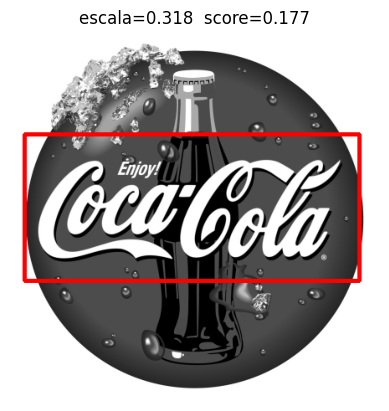

In [249]:
escala = 0.318
img_s = cv2.resize(img4, (0, 0), fx=escala, fy=escala, interpolation=cv2.INTER_AREA)

resultado = cv2.matchTemplate(img_s, template_edges, cv2.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(resultado)
print(f"escala={escala}  score={max_val:.3f}")

img_rgb = cv2.cvtColor(img_s, cv2.COLOR_GRAY2RGB)
x, y = max_loc
cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (255, 0, 0), 3)
plt.imshow(img_rgb); plt.axis('off')
plt.title(f"escala={escala}  score={max_val:.3f}")
plt.show()

Mejor escala: 0.318  score: 0.132


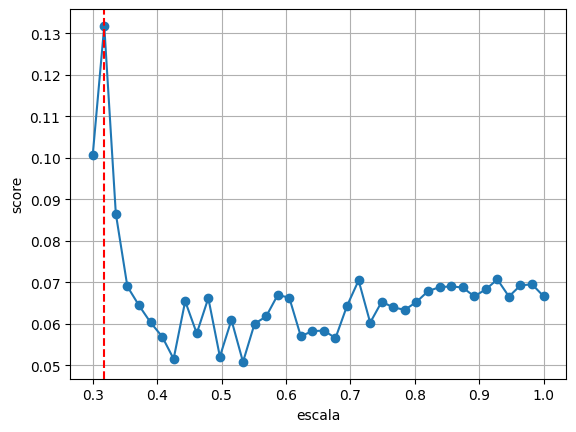

In [250]:
escalas = np.linspace(0.3, 1, 40)
scores = []

for escala in escalas:
    interp = cv2.INTER_AREA if escala < 1 else cv2.INTER_LINEAR
    img_s = cv2.resize(img4_edges, (0, 0), fx=escala, fy=escala, interpolation=interp)
    if img_s.shape[0] < h or img_s.shape[1] < w:
        scores.append(-1)
        continue
    res = cv2.matchTemplate(img_s, template_edges, cv2.TM_CCOEFF_NORMED)
    _, max_val, _, _ = cv2.minMaxLoc(res)
    scores.append(max_val)

scores = np.array(scores)
mejor = escalas[np.argmax(scores)]
print(f"Mejor escala: {mejor:.3f}  score: {scores.max():.3f}")

plt.plot(escalas, scores, marker='o')
plt.axvline(mejor, color='r', ls='--')
plt.xlabel('escala'); plt.ylabel('score'); plt.grid(True)
plt.show()

Aunque el score no es alto de manera obsoluta, se observa un pico máximo evidente para la escala 0.318. Esta detección funciona tanto con el filtro de media como sin ella. Los resultados son similares, aunque con el filtro de media mejora.

### Imagen _coca_retro_2_

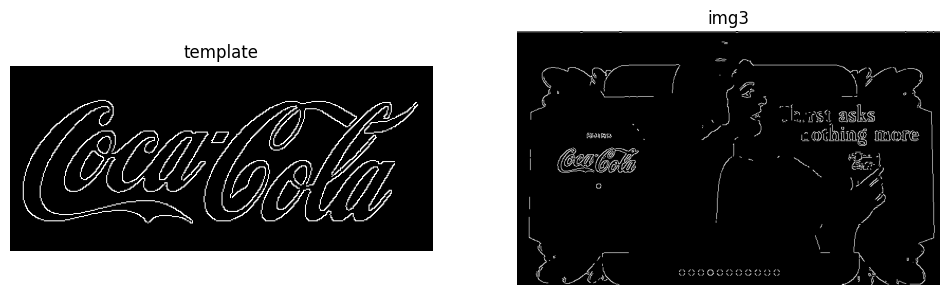

In [283]:
img5 = cv2.imread(r'images\coca_retro_2.png', cv2.IMREAD_GRAYSCALE)

template_edges = cv2.Canny(template, 100, 150)

#img5_med   = cv2.medianBlur(img5, 3)
#img5_blur   = cv2.GaussianBlur(img5, (3, 3), 0) 
img5_edges = cv2.Canny(img5, 300, 350)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(template_edges, cmap='gray')
axes[0].axis('off')
axes[0].set_title('template')
axes[1].imshow(img5_edges, cmap='gray')
axes[1].axis('off')
axes[1].set_title('img3')
plt.show()

Max value: 0.3208816349506378
Max location: (57, 182)


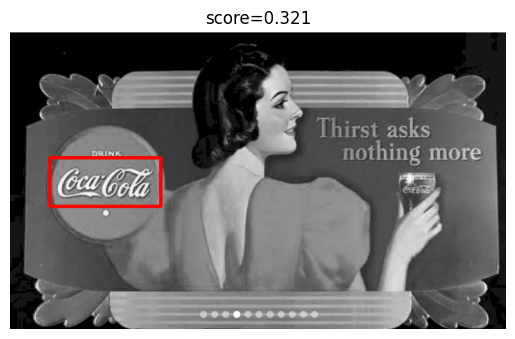

In [284]:
escala = 0.4
template_s = cv2.resize(template_edges, (0, 0), fx=escala, fy=escala, interpolation=cv2.INTER_AREA)

resultado = cv2.matchTemplate(img5_edges, template_s, cv2.TM_CCOEFF_NORMED)

min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(resultado)
print("Max value:", max_val)
print("Max location:", max_loc)

h, w = template_s.shape

img_rgb_5 = cv2.cvtColor(img5, cv2.COLOR_GRAY2RGB)
x, y = max_loc
cv2.rectangle(img_rgb_5, (x, y), (x + w, y + h), (255, 0, 0), 3)

plt.imshow(img_rgb_5); plt.axis('off')
plt.title(f"score={max_val:.3f}")
plt.show()

Mejor escala: 0.400  score: 0.321


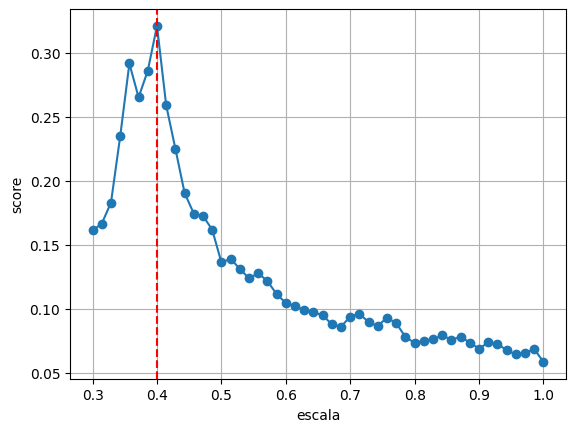

In [285]:
H, W = img5_edges.shape[:2]          # dimensiones de la imagen (fija)

escalas = np.linspace(0.3, 1.0, 50)
scores = []

for escala in escalas:
    interp = cv2.INTER_AREA if escala < 1 else cv2.INTER_LINEAR
    template_s = cv2.resize(template_edges, (0, 0), fx=escala, fy=escala, interpolation=interp)
    th, tw = template_s.shape[:2]
    if th > H or tw > W:             # el template no puede exceder la imagen
        scores.append(-1)
        continue
    res = cv2.matchTemplate(img5_edges, template_s, cv2.TM_CCOEFF_NORMED)
    _, max_val, _, _ = cv2.minMaxLoc(res)
    scores.append(max_val)

scores = np.array(scores)
mejor = escalas[np.argmax(scores)]
print(f"Mejor escala: {mejor:.3f}  score: {scores.max():.3f}")

plt.plot(escalas, scores, marker='o')
plt.axvline(mejor, color='r', ls='--')
plt.xlabel('escala'); plt.ylabel('score'); plt.grid(True)
plt.show()

Se observa que con Canny es suficiente para poder detectar correctamente el logo. Se probó también agregar un filtro gaussiano y de media, pero estos tienen más costo que beneficio, resultando en un menor score. Sucede que el logo no tiene demasiado ruido de fondo alrededor, por lo tanto no hay demasiado por suavizar o eliminar, y poro otro lado, al ser el logo muy chico, ocupa pocos píxeles por lo tanto el kernel lo afecta demasiado (especialmente el de mediana) y borra algunos de sus bordes.

### Imagen _logo_1_

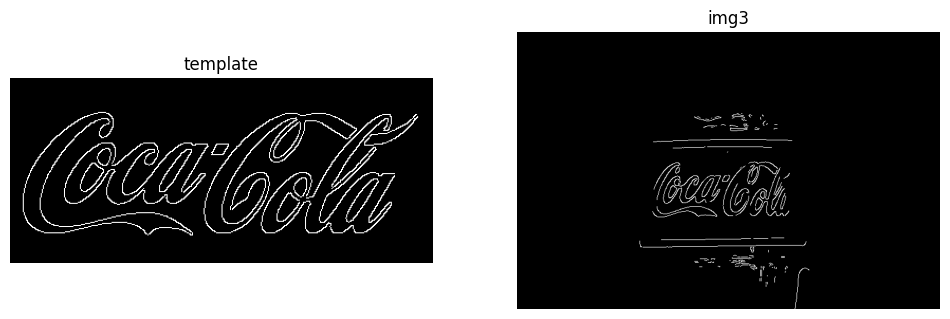

In [25]:
img6 = cv2.imread(r'images\logo_1.png', cv2.IMREAD_GRAYSCALE)

template_edges = cv2.Canny(template, 100, 150)

#img5_med   = cv2.medianBlur(img5, 3)
#img6_blur   = cv2.GaussianBlur(img6, (3, 3), 0) 

img6_edges = cv2.Canny(img6, 300, 350)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(template_edges, cmap='gray')
axes[0].axis('off')
axes[0].set_title('template')
axes[1].imshow(img6_edges, cmap='gray')
axes[1].axis('off')
axes[1].set_title('img3')
plt.show()

Se observa que la al aplicar Canny directo sobre la imagen se pierden algunos bordes dado que la imagen tiene un efecto de desenfoque en las zonas de curvatura de la botella. Se decide aplicar unsharp masking para aumentar el contenido de alta frecuncia y lograr mejorar los bordes del logo.

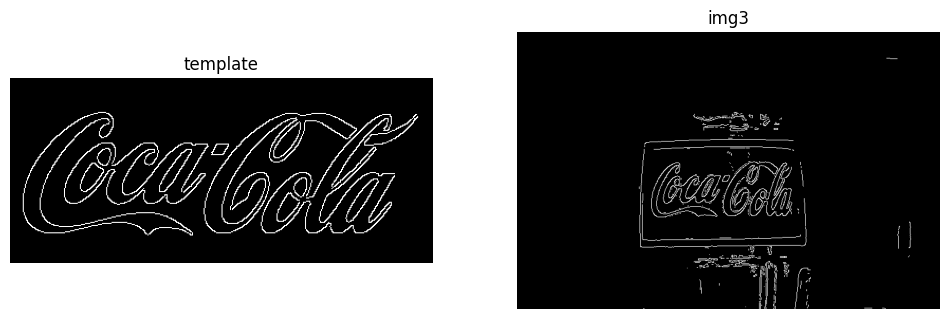

In [36]:
img6_2 = cv2.imread(r'images\logo_1.png', cv2.IMREAD_GRAYSCALE)

template_edges = cv2.Canny(template, 100, 150)

img6_2_float = img6_2.astype(np.float64) # se convierte a float y debajo se clipea para evitar el overflow > 255
img6_2_blur = cv2.GaussianBlur(img6_2_float, (5, 5), 1)
k = 3 # valor para unsharp masking clásico
img6_2_unsharp = (k + 1) * img6_2_float - k * img6_2_blur
img6_2_unsharp = np.clip(img6_2_unsharp, 0, 255).astype(np.uint8) # clipeo para limitar

img6_2_edges = cv2.Canny(img6_2_unsharp, 300, 350)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(template_edges, cmap='gray')
axes[0].axis('off')
axes[0].set_title('template')
axes[1].imshow(img6_2_edges, cmap='gray')
axes[1].axis('off')
axes[1].set_title('img3')
plt.show()

Se observa la mejora de los contornos del logo. También aparecen otros bordes reasaltados no deseados.

Se aplica el template matching a esta imagen.

Max value: 0.16598917543888092
Max location: (194, 189)


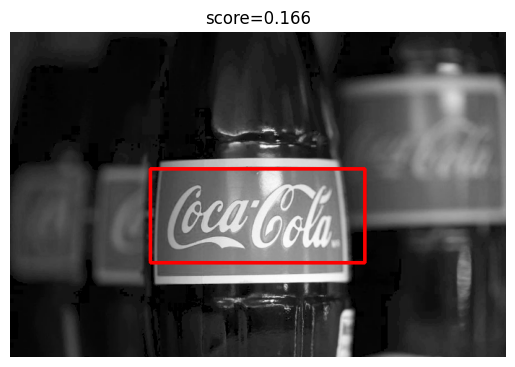

In [34]:
escala = 0.743
template_s = cv2.resize(template_edges, (0, 0), fx=escala, fy=escala, interpolation=cv2.INTER_AREA)

resultado = cv2.matchTemplate(img6_2_edges, template_s, cv2.TM_CCOEFF_NORMED)

min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(resultado)
print("Max value:", max_val)
print("Max location:", max_loc)

h, w = template_s.shape

img_rgb_6 = cv2.cvtColor(img6, cv2.COLOR_GRAY2RGB)
x, y = max_loc
cv2.rectangle(img_rgb_6, (x, y), (x + w, y + h), (255, 0, 0), 3)

plt.imshow(img_rgb_6); plt.axis('off')
plt.title(f"score={max_val:.3f}")
plt.show()

Mejor escala: 0.743  score: 0.166


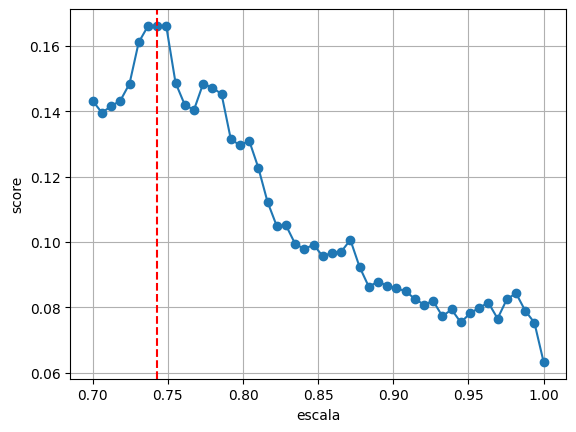

In [ ]:
H, W = img6_2_edges.shape[:2]          # dimensiones de la imagen (fija)

escalas = np.linspace(0.7, 1.0, 50)
scores = []

for escala in escalas:
    interp = cv2.INTER_AREA if escala < 1 else cv2.INTER_LINEAR
    template_s = cv2.resize(template_edges, (0, 0), fx=escala, fy=escala, interpolation=interp)
    th, tw = template_s.shape[:2]
    if th > H or tw > W:             # el template no puede exceder la imagen
        scores.append(-1)
        continue
    res = cv2.matchTemplate(img6_2_edges, template_s, cv2.TM_CCOEFF_NORMED)
    _, max_val, _, _ = cv2.minMaxLoc(res)
    scores.append(max_val)

scores = np.array(scores)
mejor = escalas[np.argmax(scores)]
print(f"Mejor escala: {mejor:.3f}  score: {scores.max():.3f}")

plt.plot(escalas, scores, marker='o')
plt.axvline(mejor, color='r', ls='--')
plt.xlabel('escala'); plt.ylabel('score'); plt.grid(True)
plt.show()

## Punto 2

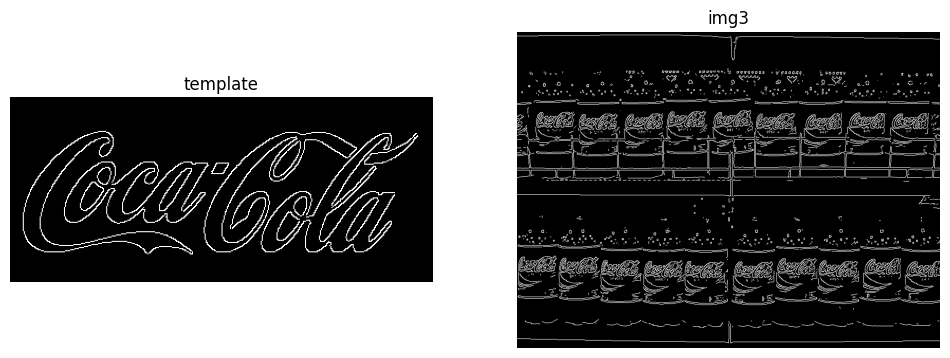

In [41]:
img_multi = cv2.imread(r'images\coca_multi.png', cv2.IMREAD_GRAYSCALE)

template_edges = cv2.Canny(template, 100, 150)

#img5_med   = cv2.medianBlur(img5, 3)
#img6_blur   = cv2.GaussianBlur(img6, (3, 3), 0) 

img_multi_edges = cv2.Canny(img_multi, 300, 350)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(template_edges, cmap='gray')
axes[0].axis('off')
axes[0].set_title('template')
axes[1].imshow(img_multi_edges, cmap='gray')
axes[1].axis('off')
axes[1].set_title('img3')
plt.show()

Max value: 0.310699999332428
Max location: (437, 148)


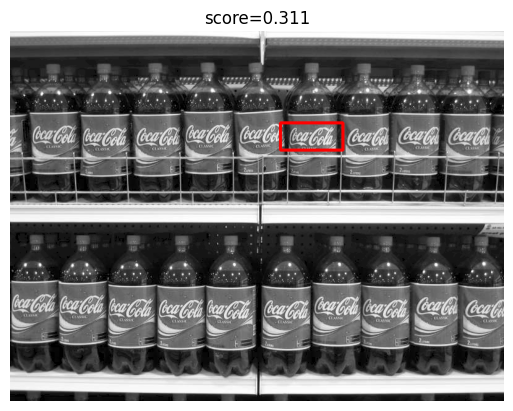

In [52]:
escala = 0.252
template_s = cv2.resize(template_edges, (0, 0), fx=escala, fy=escala, interpolation=cv2.INTER_AREA)

resultado = cv2.matchTemplate(img_multi_edges, template_s, cv2.TM_CCOEFF_NORMED)

min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(resultado)
print("Max value:", max_val)
print("Max location:", max_loc)

h, w = template_s.shape

img_multi_rgb = cv2.cvtColor(img_multi, cv2.COLOR_GRAY2RGB)
x, y = max_loc
cv2.rectangle(img_multi_rgb, (x, y), (x + w, y + h), (255, 0, 0), 3)

plt.imshow(img_multi_rgb); plt.axis('off')
plt.title(f"score={max_val:.3f}")
plt.show()

Mejor escala: 0.252  score: 0.309


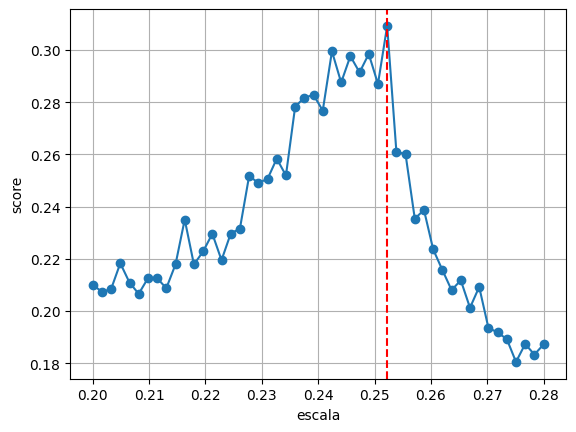

In [51]:
H, W = img_multi_edges.shape[:2]          # dimensiones de la imagen (fija)

escalas = np.linspace(0.2, 0.28, 50)
scores = []

for escala in escalas:
    interp = cv2.INTER_AREA if escala < 1 else cv2.INTER_LINEAR
    template_s = cv2.resize(template_edges, (0, 0), fx=escala, fy=escala, interpolation=interp)
    th, tw = template_s.shape[:2]
    if th > H or tw > W:             # el template no puede exceder la imagen
        scores.append(-1)
        continue
    res = cv2.matchTemplate(img_multi_edges, template_s, cv2.TM_CCOEFF_NORMED)
    _, max_val, _, _ = cv2.minMaxLoc(res)
    scores.append(max_val)

scores = np.array(scores)
mejor = escalas[np.argmax(scores)]
print(f"Mejor escala: {mejor:.3f}  score: {scores.max():.3f}")

plt.plot(escalas, scores, marker='o')
plt.axvline(mejor, color='r', ls='--')
plt.xlabel('escala'); plt.ylabel('score'); plt.grid(True)
plt.show()

Ahora, en el siguiente paso pasamos a marcar todos los puntos donde el resultado del template matching supere al umbral.

cajas dibujadas: 26


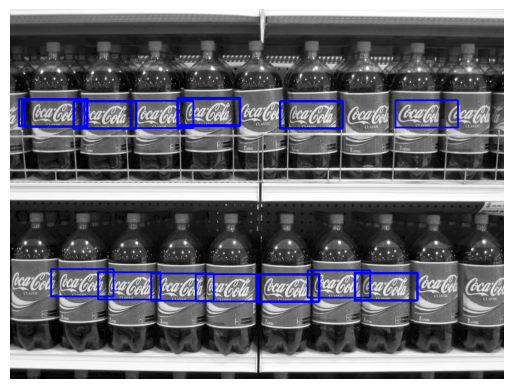

In [ ]:
escala = 0.252 # se toma esta escala del paso anterior
template_s = cv2.resize(template_edges, (0, 0), fx=escala, fy=escala, interpolation=cv2.INTER_AREA)
th, tw = template_s.shape[:2]

res = cv2.matchTemplate(img_multi_edges, template_s, cv2.TM_CCOEFF_NORMED)

umbral = 0.2
loc = np.where(res >= umbral) # todos los puntos donde se supera el umbral

img_rgb = cv2.cvtColor(img_multi, cv2.COLOR_GRAY2RGB) 
for (y, x) in zip(*loc):
    cv2.rectangle(img_rgb, (x, y), (x + tw, y + th), (0, 0, 255), 2)

print("cajas dibujadas:", len(loc[0]))
plt.imshow(img_rgb); plt.axis('off'); plt.show()

Se observa que hay cajas solapadas, es decir, se señalan pixeles cercanos como puntos desde donde la correlación con el template supera al umbral. Para solucionar esto se deben comparar las cajas y descartar las que tengan alto solapamiento entre sí.

Para eso, en el próximo paso se comienzan a guardar las coordenadas de las cajas.

In [ ]:
escala = 0.252
template_s = cv2.resize(template_edges, (0, 0), fx=escala, fy=escala, interpolation=cv2.INTER_AREA)
th, tw = template_s.shape[:2]

res = cv2.matchTemplate(img_multi_edges, template_s, cv2.TM_CCOEFF_NORMED)

umbral = 0.20
ys, xs = np.where(res >= umbral)

boxes  = np.array([[x, y, x + tw, y + th] for x, y in zip(xs, ys)])  # (x1,y1,x2,y2) --> para cada caja
scores = res[ys, xs]

A continuación se define la función que va a ordenar todas las cajas en función del score y luego irá comparando sus solapamientos a través del índice de IoU que indica justamente cuán solapadas están. Si da cercano a 1, se decarta la nueva caja evaluada.

In [ ]:
def nms(boxes, scores, iou_thr):
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    areas = (x2 - x1) * (y2 - y1)
    orden = scores.argsort()[::-1]          # índices de mayor a menor score (el -1 invierte)

    keep = []
    while orden.size > 0:
        i = orden[0]                        
        keep.append(i)

        # intersección de i con todas las demás
        xx1 = np.maximum(x1[i], x1[orden[1:]])
        yy1 = np.maximum(y1[i], y1[orden[1:]])
        xx2 = np.minimum(x2[i], x2[orden[1:]])
        yy2 = np.minimum(y2[i], y2[orden[1:]])

        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)
        inter = w * h
        iou = inter / (areas[i] + areas[orden[1:]] - inter)

        orden = orden[1:][iou <= iou_thr]   # me quedo con los que NO son duplicados

    return keep

detecciones: 13


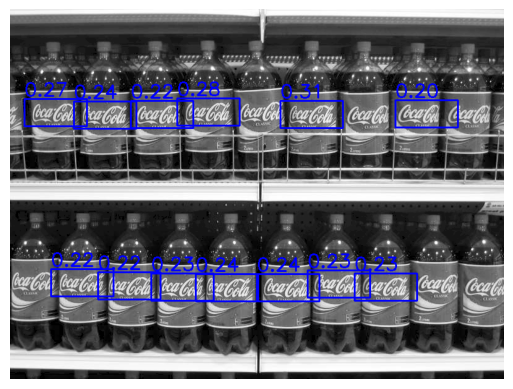

In [66]:
keep = nms(boxes, scores, iou_thr=0.3)

img_multi_rgb = cv2.cvtColor(img_multi, cv2.COLOR_GRAY2RGB)
for i in keep:
    x1, y1, x2, y2 = boxes[i]
    cv2.rectangle(img_multi_rgb, (x1, y1), (x2, y2), (0, 0, 255), 2)
    cv2.putText(img_multi_rgb, f"{scores[i]:.2f}", (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)

print(f"detecciones: {len(keep)}")
plt.imshow(img_multi_rgb); plt.axis('off'); plt.show()

Se observa que ahora coinciden la cantidad de cajas con la cantidad de logos señalados.